In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
import numpy as np
import warnings
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('future.no_silent_downcasting', True)

In [38]:
# Loading data
df = pd.read_excel('processed_file_new.xlsx')

In [39]:
df.head()

,category,price,currency,price_1m2,title,address,area,title_deed,repair,room_number,region,region_new
0,kohne,137 000,AZN,2 630 AZN/m²,"Satilir 3 otaqli kohne tikili 52 m², 8-ci kilo...",Elshen Suleymanov kuc 137,52 m²,var,var,3,8-ci kilometr,Nizami
1,yeni,183 000,AZN,1 790 AZN/m²,"Satilir 2 otaqli yeni tikili 102 m², Neftchile...",Mehdi Abbasov kucesi,102 m²,yoxdur,var,2,Neftchiler,Nizami
2,kohne,145 000,AZN,2 230 AZN/m²,"Satilir 2 otaqli kohne tikili 65 m², Nerimanov r.",Ataturk Prospekti,65 m²,var,var,2,Nerimanov,Nerimanov
3,kohne,190 000,AZN,2 000 AZN/m²,"Satilir 3 otaqli kohne tikili 95 m², Genclik m.",Ataturk pr,95 m²,var,var,3,Genclik,Nerimanov
4,yeni,294 000,AZN,1 550 AZN/m²,"Satilir 3 otaqli yeni tikili 190 m², Nesimi r.",Mohsun Senani kucesi,190 m²,var,yoxdur,3,Nesimi,Nerimanov


In [40]:
df['repair'].replace(r'^\s*$', 'yoxdur', regex=True, inplace=True) #Replaced empty strings or NaNs with 'no'
df['repair'].fillna('yoxdur', inplace=True)

df.replace({'repair': {'var': 1, 'yoxdur': 0}}, inplace=True)     # Replaced categorical strings with numerical codes for certain columns
df.replace({'title_deed': {'var': 1, 'yoxdur': 0}}, inplace=True)
df.replace({'category': {'yeni': 1, 'kohne': 0}}, inplace=True)

df['title_deed'] = df['title_deed'].astype(int)
df['repair'] = df['repair'].astype(int)

df['area'] = df['area'].str.replace('m²', '', regex=False).str.replace(' ', '').str.split('.').str[0].astype(int) #Cleaned numeric columns
df['price'] = df['price'].str.replace(' ', '').astype(int)
df['room_number'] = df['room_number'].astype(int)

df.drop(columns=['currency', 'title', 'address', 'region'], inplace=True)
df.drop('price_1m2', axis=1, inplace=True)
#df.info()
df = df[~df['region_new'].isin(['Pirallahi', 'Qaradag'])]

df = pd.get_dummies(df, columns=['region_new'], prefix='region').astype(int)

In [41]:
X = df.drop(columns=['price'])
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [42]:
forest = RandomForestRegressor()
forest.fit(X_train, y_train)
y_pred = forest.predict(X_test)

Mean Absolute Error: 41490.92 AZN
R-squared Score: 0.7605


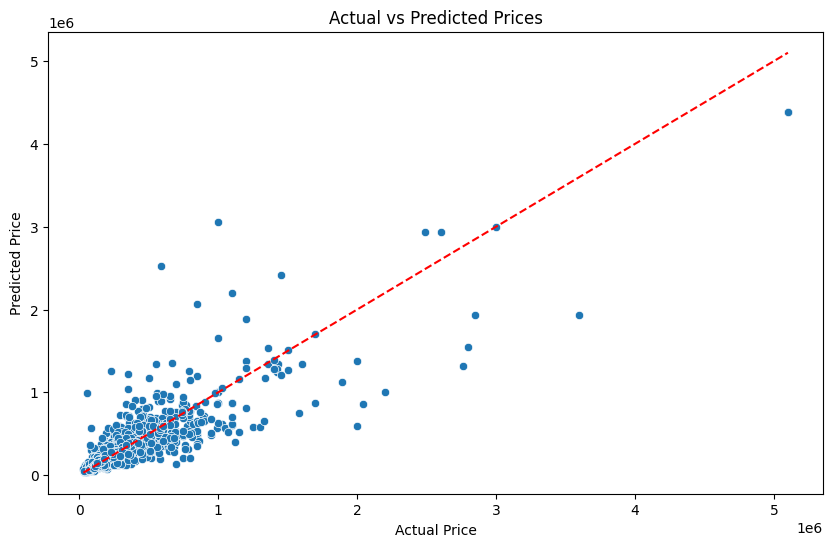

In [43]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} AZN")
print(f"R-squared Score: {r2:.4f}")

# Optional: Visual check
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()